### SentiSBERT KG-GNN Model


In [177]:
import random
import numpy as np
import torch
import os
import pandas as pd
from textblob import TextBlob
import ast
import networkx as nx
from torch_geometric.data import HeteroData
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HANConv
from torch.utils.data import DataLoader, TensorDataset, Dataset
from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

### 1. Random Seed Setup

In [178]:
def set_random_seed(seed=42):
    # Python random
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Ensure CUDA operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Random seed set to {seed} for reproducibility")
    print(f"   - Python random: {seed}")
    print(f"   - NumPy: {seed}")
    print(f"   - PyTorch: {seed}")
    print(f"   - CUDA deterministic: True")
    print(f"   - Python hash seed: {seed}")

# Set random seed
set_random_seed(42)

Random seed set to 42 for reproducibility
   - Python random: 42
   - NumPy: 42
   - PyTorch: 42
   - CUDA deterministic: True
   - Python hash seed: 42


### 2. Data Loading 

In [179]:
HISTORY_LIMIT = 7  # Set to None for no limit
def cap_front_list(history_list, limit=HISTORY_LIMIT):
    if limit is not None and len(history_list) > limit:
        history_list = history_list[limit:]
    return history_list

def cap_front_string(history_str, limit=HISTORY_LIMIT):
    # tolerate NaN/None and non‑string inputs
    if not isinstance(history_str, str):
        return ''  # or return history_str as-is if you prefer
    tokens = history_str.strip().split()
    # keep your original capping rule here:
    # from the *front* (adjust to your logic)
    tokens = cap_front_list(tokens, limit=limit)
    if limit is None:
        return ' '.join(tokens)
    return ' '.join(tokens[:limit])


In [180]:
behaviour = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/behaviors.tsv', sep='\t', 
                        names=["Impression_ID", "User_ID", "Time", "History", "Impressions"])

news = pd.read_csv('./kaggle/input/mind-news-dataset/MINDsmall_train/news.tsv', sep='\t',
                   names=["News_ID", "Category", "SubCategory", "Title", "Abstract", "URL", "Title_Entities", "Abstract_Entities"])


print('News sample:')
print(news.head())
print('behaviour sample:')
print(behaviour.head())

# Load entity_embedding.vec
entity_emb = {}
with open('./kaggle/input/mind-news-dataset/MINDsmall_train/entity_embedding.vec', 'r') as f:
    for line in f:
        parts = line.strip().split()
        entity_id = parts[0]
        emb = np.array([float(x) for x in parts[1:]])
        entity_emb[entity_id] = emb
print('Sample entity embedding:', list(entity_emb.items())[:1])

News sample:
  News_ID   Category      SubCategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   
2  N61837       news        newsworld   
3  N53526     health           voices   
4  N38324     health          medical   

                                               Title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   
2  The Cost of Trump's Aid Freeze in the Trenches...   
3  I Was An NBA Wife. Here's How It Affected My M...   
4  How to Get Rid of Skin Tags, According to a De...   

                                            Abstract  \
0  Shop the notebooks, jackets, and more that the...   
1  These seemingly harmless habits are holding yo...   
2  Lt. Ivan Molchanets peeked over a parapet of s...   
3  I felt like I was a fraud, and being an NBA wi...   
4  They seem harmless, but there's a very good re...   

                                             URL  \
0  https://ass

### 3. Data Cleaning

In [181]:
def parse_impressions(imp_str):
    if pd.isna(imp_str):
        return []
    items = imp_str.strip().split(' ')
    return [(i.split('-')[0], int(i.split('-')[1])) for i in items]

behaviour['Impressions_parsed'] = behaviour['Impressions'].apply(parse_impressions)
behaviour['History'] = behaviour['History'].apply(cap_front_string)
def parse_history(history_str):
    if pd.isna(history_str):
        return []
    return history_str.strip().split(' ')

behaviour['History_parsed'] = behaviour['History'].apply(parse_history)

def check_df_shape_and_null(df):
    print("The shape of df:", df.shape)
    df.info()
    
    print("\nThe number of missing values in each column:")
    print(df.isnull().sum())

news_clean = news.dropna()
news_clean.drop_duplicates(subset=['News_ID'], inplace=True)

behaviour_clean = behaviour.dropna()
behaviour_clean.drop_duplicates(subset=['Impression_ID'], inplace=True)

check_df_shape_and_null(news_clean)
check_df_shape_and_null(behaviour_clean)

The shape of df: (48612, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 48612 entries, 0 to 51280
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   News_ID            48612 non-null  object
 1   Category           48612 non-null  object
 2   SubCategory        48612 non-null  object
 3   Title              48612 non-null  object
 4   Abstract           48612 non-null  object
 5   URL                48612 non-null  object
 6   Title_Entities     48612 non-null  object
 7   Abstract_Entities  48612 non-null  object
dtypes: object(8)
memory usage: 3.3+ MB

The number of missing values in each column:
News_ID              0
Category             0
SubCategory          0
Title                0
Abstract             0
URL                  0
Title_Entities       0
Abstract_Entities    0
dtype: int64
The shape of df: (156965, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156965 entries, 0 to 156964
Data colu

/tmp/ipykernel_810139/4138317946.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean.drop_duplicates(subset=['News_ID'], inplace=True)



### 4. Entity Analysis 

In [182]:
def has_entities(x):
    if pd.isna(x) or str(x).strip() == "":
        return False
    try:
        ents = ast.literal_eval(x)
        return isinstance(ents, list) and len(ents) > 0
    except Exception:
        return False

# Calculate the proportion of titles without entities and abstracts without entities.
frac_title_empty = 1 - news_clean['Title_Entities'].apply(has_entities).mean()
frac_abs_empty   = 1 - news_clean['Abstract_Entities'].apply(has_entities).mean()

print(f"Title Missing columns: {frac_title_empty:.1%}")
print(f"Abstract Missing columns: {frac_abs_empty:.1%}")

Title Missing columns: 27.1%
Abstract Missing columns: 23.0%


### 5. Sentiment Analysis

In [183]:
def get_sentiment(text):
    if pd.isnull(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

# Apply sentiment analysis to news titles
news_clean['sentiment_score_title'] = news_clean['Title']   .apply(get_sentiment)

print(news_clean[['Title','sentiment_score_title']].head())

                                               Title  sentiment_score_title
0  The Brands Queen Elizabeth, Prince Charles, an...                    0.0
1                      50 Worst Habits For Belly Fat                   -1.0
2  The Cost of Trump's Aid Freeze in the Trenches...                    0.0
3  I Was An NBA Wife. Here's How It Affected My M...                   -0.1
4  How to Get Rid of Skin Tags, According to a De...                    0.0


/tmp/ipykernel_810139/212460997.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_clean['sentiment_score_title'] = news_clean['Title']   .apply(get_sentiment)


### 6.Data Processing for title entities 

In [184]:
# Define default entity IDs
news_clean=news_clean.copy()
GLOBAL_DEFAULT_TITLE = 'GLOBAL_DEFAULT_TITLE'
GLOBAL_DEFAULT_ABS   = 'GLOBAL_DEFAULT_ABS'

def fill_title_entities(row):
    try:
        ents = ast.literal_eval(row['Title_Entities'])
    except:
        ents = []
    return ents if ents else [{'Label': GLOBAL_DEFAULT_TITLE}]

# Process title entities
news_clean['Title_Entities_Processed']    = news_clean.apply(fill_title_entities, axis=1)

#Calculate entity sentiment averages
entity_sent_title = {}
for _, row in news_clean.iterrows():
    score = get_sentiment(row['Title'])
    for ent in row['Title_Entities_Processed']:
        eid = ent['Label']
        if eid == GLOBAL_DEFAULT_TITLE: 
            continue
        entity_sent_title.setdefault(eid, []).append(score)

entity_sentiment_title_avg = {
    eid: sum(v)/len(v) 
    for eid, v in entity_sent_title.items()
}
# Set default sentiment for global entities
default_title_sent = np.mean(list(entity_sentiment_title_avg.values()))
entity_sentiment_title_avg[GLOBAL_DEFAULT_TITLE] = default_title_sent

#Add embeddings for global entities
all_embs    = np.array(list(entity_emb.values()))
default_emb = all_embs.mean(axis=0)
entity_emb[GLOBAL_DEFAULT_TITLE] = default_emb

print(news_clean.head)

<bound method NDFrame.head of       News_ID   Category               SubCategory  \
0      N55528  lifestyle           lifestyleroyals   
1      N19639     health                weightloss   
2      N61837       news                 newsworld   
3      N53526     health                    voices   
4      N38324     health                   medical   
...       ...        ...                       ...   
51275  N17258       news  newsscienceandtechnology   
51276  N23858     sports                      golf   
51277  N16909    weather         weathertopstories   
51279   N7482     sports               more_sports   
51280  N34418     sports                soccer_epl   

                                                   Title  \
0      The Brands Queen Elizabeth, Prince Charles, an...   
1                          50 Worst Habits For Belly Fat   
2      The Cost of Trump's Aid Freeze in the Trenches...   
3      I Was An NBA Wife. Here's How It Affected My M...   
4      How to Get Rid

### 7.Split dataset to 80% training and 20% testing

In [185]:
def split_by_impression(behaviour_clean, test_ratio=0.2):
    behaviour_sorted = behaviour_clean.sort_values('Time')
    # split by Impression
    split_idx = int(len(behaviour_sorted) * (1 - test_ratio))
    train_behaviour = behaviour_sorted.iloc[:split_idx]
    test_behaviour = behaviour_sorted.iloc[split_idx:]
    # test_behaviour['History'] = test_behaviour['History'].apply(cap_front_string)   #ray
    # test_behaviour['History_parsed'] = test_behaviour['History_parsed'].apply(cap_front_list) #ray
    return train_behaviour, test_behaviour

train_behaviour, test_behaviour = split_by_impression(behaviour_clean, test_ratio=0.2) 

In [186]:
#Sample users for efficiency
sample_ratio = 0.2
user_ids_sub = train_behaviour['User_ID'].unique()
sampled_users_sub = np.random.choice(user_ids_sub, size=int(len(user_ids_sub) * sample_ratio), replace=False)

# Filter behavior for sampled users
train_behaviour_sub = train_behaviour[train_behaviour['User_ID'].isin(sampled_users_sub)].copy()
test_behaviour_sub = test_behaviour[test_behaviour['User_ID'].isin(sampled_users_sub)].copy()

# Find news IDs involved in sampled behavior
news_ids_in_history = set()
for h in train_behaviour_sub['History']:
    news_ids_in_history.update(str(h).split())
if 'Impressions' in train_behaviour_sub.columns:
    for imp in train_behaviour_sub['Impressions']:
        news_ids_in_history.update([i.split('-')[0] for i in str(imp).split()])

#Keep only relevant news
news_clean = news_clean[news_clean['News_ID'].isin(news_ids_in_history)].copy()

### 8. Knowledge Graph Construction (Illustration)

In [187]:
G = nx.Graph()

# Add news nodes with sentiment
for idx, row in news_clean.iterrows():
    G.add_node(row['News_ID'], node_type='news', sentiment=row['sentiment_score_title'])

# Add entity nodes and news-entity edges
for idx, row in news_clean.iterrows():
    try:
        entities = row['Title_Entities_Processed']
    except:
        entities = []
    for ent in entities:
        ent_label = ent.get('Label', '')
        if ent_label:
            ent_emb = entity_emb.get(ent_label, np.zeros(100))
            ent_sent = entity_sentiment_title_avg.get(ent_label, 0)
            G.add_node(ent_label, node_type='entity', features=np.concatenate([ent_emb, [ent_sent]]))
            G.add_edge(row['News_ID'], ent_label, edge_type='has_entity')

# Add user-news interactions
for idx, row in train_behaviour_sub.iterrows():
    user = row['User_ID']
    history = str(row['History']).split()
    for news_id in history:
        G.add_node(user, node_type='user')
        G.add_edge(user, news_id, edge_type='clicked')

print(f'Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')



Graph has 36475 nodes and 74871 edges.


### 9. Feature Engineering

In [188]:
#9.1 Prepare mappings and lists
news_id_list = news_clean['News_ID'].tolist()
news2idx     = {nid:i for i,nid in enumerate(news_id_list)}

user_id_list = train_behaviour_sub['User_ID'].unique().tolist()
user2idx     = {uid:i for i,uid in enumerate(user_id_list)}

entity_id_list = list(entity_emb.keys())
emb_dim        = len(next(iter(entity_emb.values())))
entity2idx     = {eid:i for i,eid in enumerate(entity_id_list)}

sent_map = news_clean.set_index('News_ID')['sentiment_score_title'].to_dict()
ent_lists = news_clean['Title_Entities_Processed'].tolist()


In [189]:
#=============================================================================================
#9.2 Building up News node features
#=============================================================================================

#9.2.1 Sentiment score feature
news_sentiment = news_clean['sentiment_score_title'].values.reshape(-1, 1)  # shape: (N_news, 1)

#9.2.2 One-hot features for "category" data
categories = news_clean['Category'].unique().tolist()
cat2idx = {cat: i for i, cat in enumerate(categories)}
news_cat_feat = np.zeros((len(news_clean), len(categories)))
for i, cat in enumerate(news_clean['Category']):
    news_cat_feat[i, cat2idx[cat]] = 1  # shape: (N_news, num_categories)

#9.2.3 TF-IDF text features for "title" data
vectorizer = TfidfVectorizer(max_features=100)
tfidf_feat = vectorizer.fit_transform(news_clean['Title'].fillna('')).toarray()  # shape: (N_news, 100)

#9.2.4 SBERT embeddings for "title" and "abstract"data
sbert = SentenceTransformer('paraphrase-MiniLM-L6-v2')
news_texts = (news_clean['Title'].fillna('') + ' ' + news_clean['Abstract'].fillna('')).tolist()
bert_feat = sbert.encode(news_texts, show_progress_bar=True, batch_size=128)
scaler = StandardScaler()
bert_feat_norm = scaler.fit_transform(bert_feat)

#9.2.5 Combine all above four news features
news_x = np.hstack([news_sentiment, news_cat_feat, tfidf_feat,bert_feat_norm])  # shape: (N_news, 1+num_categories+100)
news_x = torch.tensor(news_x, dtype=torch.float)

#=============================================================================================
#9.3 Building up Entity node features using entity_sentiment_title_avg data
#=============================================================================================

entity_x_np = np.array([
    np.concatenate([
        entity_emb[eid],
        [entity_sentiment_title_avg.get(eid, 0.0)]
    ])
    for eid in entity_id_list
])
entity_x = torch.tensor(entity_x_np, dtype=torch.float)


#=============================================================================================
# 9.4 Building up User node features 
#=============================================================================================

news_id2cat = news_clean.set_index('News_ID')['Category'].to_dict()
categories = list(news_clean['Category'].unique())
cat2idx = {cat: i for i, cat in enumerate(categories)}

#9.4.1 User category distribution
user_cat_feat = np.zeros((len(user_id_list), len(categories)))
for i, uid in enumerate(user_id_list):
    user_hist = train_behaviour_sub[train_behaviour_sub['User_ID'] == uid]['History']
    news_ids = []
    for h in user_hist:
        news_ids += str(h).split()
    for nid in news_ids:
        cat = news_id2cat.get(nid, None)
        if cat is not None:
            user_cat_feat[i, cat2idx[cat]] += 1
#Normalize category features
user_cat_feat = user_cat_feat / (user_cat_feat.sum(axis=1, keepdims=True) + 1e-8)

#9.4.2 Time-decayed user embedding features
def temporal_weight(time_diff_hours):
    if time_diff_hours == 0:
        return 1.0
    # logarithmic decay：1 / (1 + log(1 + hours/12))
    return 1.0 / (1.0 + np.log(1 + time_diff_hours / 12))

#Parse time string
def parse_time(time_str):
    try:
        return datetime.strptime(time_str, "%m/%d/%Y %I:%M:%S %p")
    except:
        return datetime.now()

# Get reference time
latest_time = None
for _, row in train_behaviour_sub.iterrows():
    current_time = parse_time(row['Time'])
    if latest_time is None or current_time > latest_time:
        latest_time = current_time

print(f"reference time: {latest_time}")

# Calculate time-decayed user embeddings
user_emb_feat = np.zeros((len(user_id_list), news_x.shape[1]))

for i, uid in enumerate(user_id_list):
    user_hist = train_behaviour_sub[train_behaviour_sub['User_ID'] == uid]
    
    if len(user_hist) == 0:
        continue
    
  # Calculate weighted average
    user_news_weights = []
    for _, row in user_hist.iterrows():
        behavior_time = parse_time(row['Time'])
        time_diff_hours = (latest_time - behavior_time).total_seconds() / 3600
        time_weight = temporal_weight(time_diff_hours)
        

        history_news_ids = str(row['History']).split()
        
        for news_id in history_news_ids:
            if news_id in news2idx:
                news_idx = news2idx[news_id]
                user_news_weights.append((news_x[news_idx].numpy(), time_weight))
    if user_news_weights:
        total_weight = sum(weight for _, weight in user_news_weights)
        weighted_sum = np.zeros(news_x.shape[1])
        
        for news_emb, weight in user_news_weights:
            weighted_sum += news_emb * weight
        
        user_emb_feat[i] = weighted_sum / total_weight
    else:
        user_emb_feat[i] = np.zeros(news_x.shape[1])


#9.4.3 Combine user features
user_feat = np.hstack([user_cat_feat, user_emb_feat])
user_x = torch.tensor(user_feat, dtype=torch.float)




Batches:   0%|          | 0/154 [00:00<?, ?it/s]

reference time: 2019-11-14 23:58:51


### 10. Edge Construction 

In [190]:
# News-entity edges
news_src = []
ent_dst  = []
for i, ents in enumerate(ent_lists):
    for ent in ents:
        eid = ent.get('WikidataId', ent.get('Label'))
        if eid in entity2idx:
            news_src.append(i)
            ent_dst.append(entity2idx[eid])


# User-news edges
user_src = []
news_dst = []
for row in train_behaviour_sub.itertuples(index=False):
    uidx = user2idx[row.User_ID]
    for nid in str(row.History).split():
        if nid in news2idx:
            user_src.append(uidx)
            news_dst.append(news2idx[nid])


### 11. Heterogeneous Graph Construction

In [191]:
data = HeteroData()
data['news'].x   = news_x
data['entity'].x = entity_x
data['user'].x   = user_x

data['user','clicked','news'].edge_index     = torch.tensor([user_src, news_dst], dtype=torch.long)
data['news','has_entity','entity'].edge_index = torch.tensor([news_src, ent_dst ], dtype=torch.long)

print(data)


HeteroData(
  news={ x=[19603, 502] },
  entity={ x=[26905, 101] },
  user={ x=[9183, 519] },
  (user, clicked, news)={ edge_index=[2, 137117] },
  (news, has_entity, entity)={ edge_index=[2, 27332] }
)


### 12. KGAT Model Definition 

In [192]:
# Add reverse edges for HANConv
data['news', 'clicked_by', 'user'].edge_index = data['user', 'clicked', 'news'].edge_index[[1,0], :]
data['entity', 'entity_of', 'news'].edge_index = data['news', 'has_entity', 'entity'].edge_index[[1,0], :]

class SentimentKGAT(torch.nn.Module):
    def __init__(self, hidden_dim, entity_emb_dim,dropout=0.2):
        super().__init__()
        in_channels = {
    'news': news_x.shape[1],
    'entity': entity_x.shape[1],
    'user': user_x.shape[1]
}
        self.han = HANConv(in_channels=in_channels,out_channels=hidden_dim,metadata=data.metadata())
        self.dropout = nn.Dropout(dropout)
        self.lin = torch.nn.Linear(hidden_dim, 1) 

    def forward(self, data):
        x_dict = self.han(data.x_dict, data.edge_index_dict)
        for k in x_dict:
            x_dict[k] = self.dropout(x_dict[k])
        return x_dict


### 13. Training Data Generation

In [193]:
def generate_balanced_samples(train_behaviour_sub, user2idx, news2idx, neg_ratio=4):
    """Generate balanced samples with 1:4 positive to negative ratio"""
    pos_user_idx, pos_news_idx, neg_user_idx, neg_news_idx = [], [], [], []
    
    for _, row in train_behaviour_sub.iterrows():
        user_id = row['User_ID']
        user_idx = user2idx.get(user_id, None)
        if user_idx is None:
            continue
            
        impressions = str(row['Impressions']).split()
        user_pos_news = []
        user_neg_news = []
        
        for imp in impressions:
            if '-' in imp:
                news_id, label = imp.rsplit('-', 1)
                label = int(label)
                news_idx = news2idx.get(news_id, None)
                
                if news_idx is None:
                    continue
                    
                if label == 1:
                    user_pos_news.append(news_idx)
                elif label == 0:
                    user_neg_news.append(news_idx)
        
        # Add all positive samples
        for news_idx in user_pos_news:
            pos_user_idx.append(user_idx)
            pos_news_idx.append(news_idx)
        
        # Negative sampling
        if user_pos_news and user_neg_news:
            for _ in range(len(user_pos_news) * neg_ratio):
                neg_news_idx_selected = random.choice(user_neg_news)
                neg_user_idx.append(user_idx)
                neg_news_idx.append(neg_news_idx_selected)
    
    return pos_user_idx, pos_news_idx, neg_user_idx, neg_news_idx

# Generate training samples
train_pos_user_idx, train_pos_news_idx, train_neg_user_idx, train_neg_news_idx = generate_balanced_samples(
    train_behaviour_sub, user2idx, news2idx, neg_ratio=4
)

# Create training data loader
train_user_idx = torch.tensor(train_pos_user_idx + train_neg_user_idx, dtype=torch.long)
train_news_idx = torch.tensor(train_pos_news_idx + train_neg_news_idx, dtype=torch.long)
train_labels = torch.tensor([1] * len(train_pos_user_idx) + [0] * len(train_neg_user_idx), dtype=torch.float)

train_dataset = TensorDataset(train_user_idx, train_news_idx, train_labels)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Create test data loader (preserve original impression format)
class TestDataset(Dataset):
    def __init__(self, df):
        self.rows = df.to_dict('records')
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        return self.rows[idx]

test_dataset = TestDataset(test_behaviour_sub)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Print statistics
print(f"Training users: {train_behaviour_sub['User_ID'].nunique()}")
print(f"Test users: {test_behaviour_sub['User_ID'].nunique()}")
print(f"Training positive samples: {len(train_pos_user_idx)}")
print(f"Training negative samples: {len(train_neg_user_idx)}")
print(f"Training positive/negative ratio: 1:{len(train_neg_user_idx)/len(train_pos_user_idx):.2f}")
print(f"Test impressions: {len(test_behaviour_sub)}")


Training users: 9183
Test users: 3287
Training positive samples: 35448
Training negative samples: 141452
Training positive/negative ratio: 1:3.99
Test impressions: 5202


### 14. Model Training 

In [194]:
# Setup device and model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

entity_emb_dim = len(next(iter(entity_emb.values()))) 
model = SentimentKGAT(hidden_dim=128, entity_emb_dim=entity_emb_dim).to(device)
data.to(device)  

# Setup loss function with class weights
pos_weight = len(train_neg_user_idx) / len(train_pos_user_idx)
print(f"Positive sample weight: {pos_weight:.2f}")
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
pos_weight_tensor = torch.tensor([pos_weight]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


# Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#CUDA timer
start_evt = torch.cuda.Event(enable_timing=True)
end_evt   = torch.cuda.Event(enable_timing=True)

Using device: cuda
Positive sample weight: 3.99


In [195]:
num_epochs = 10
train_losses = []
epoch_times = []

for epoch in range(1, num_epochs + 1):
    model.train()
    start_time = time.time()
    total_loss = 0.0
    
    for u_idx, n_idx, lbl in tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False):
        u_idx, n_idx, lbl = u_idx.to(device), n_idx.to(device), lbl.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data)
        u_emb = out['user'][u_idx]
        n_emb = out['news'][n_idx]
        
        # Calculate recommendation scores
        logits = (u_emb * n_emb).sum(dim=1)
        loss = criterion(logits, lbl)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    elapsed = time.time() - start_time
    train_losses.append(train_loss)
    epoch_times.append(elapsed)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Time={elapsed:.1f}s")

print("Training completed！")


Epoch 1 Training:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.0955, Time=7.9s


Epoch 2 Training:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 2: Train Loss=1.0797, Time=7.7s


Epoch 3 Training:   0%|          | 0/692 [00:00<?, ?it/s]

...

Epoch 8: Train Loss=1.0502, Time=7.7s


Epoch 9 Training:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 9: Train Loss=1.0463, Time=7.8s


Epoch 10 Training:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 10: Train Loss=1.0429, Time=7.9s
Training completed！


### 15. Model Testing 


In [196]:
model.eval()
all_scores = []
all_labels = []
all_users = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        row = batch
        
        user_id = row['User_ID']
        if isinstance(user_id, list):
            user_id = user_id[0]
        
        impressions = row['Impressions_parsed']
        
        if user_id not in user2idx:
            continue
            
        user_idx = user2idx[user_id]
        user_idx_tensor = torch.tensor([user_idx]).to(device)
        
        # Get user embedding
        out = model(data)
        user_emb = out['user'][user_idx_tensor]
        
        # Process each impression
        for impression in impressions:
            news_id_tuple = impression[0]
            news_id = news_id_tuple[0]  
            
            label_tensor = impression[1]
            label = label_tensor.item()  
            
            if news_id not in news2idx:
                continue
                
            news_idx = news2idx[news_id]
            news_idx_tensor = torch.tensor([news_idx]).to(device)
            
             # Get news embedding
            news_emb = out['news'][news_idx_tensor]
            
            # Calculate recommendation score
            score = (user_emb * news_emb).sum(dim=1).cpu().item()
            
            all_scores.append(score)
            all_labels.append(label)
            all_users.append(user_idx)

# Convert to numpy arrays
all_scores = np.array(all_scores)
all_labels = np.array(all_labels)
all_users = np.array(all_users)

print(f"Collected samples: {len(all_scores)}")
print(f"Collected labels: {len(all_labels)}")
print(f"Collected users: {len(all_users)}")
print(f"Positive samples: {np.sum(all_labels)}")
print(f"Negative samples: {len(all_labels) - np.sum(all_labels)}")



Testing:   0%|          | 0/5202 [00:00<?, ?it/s]

Collected samples: 182403
Collected labels: 182403
Collected users: 182403
Positive samples: 7031
Negative samples: 175372


### 16. Evaluation Metrics

In [197]:
def evaluate_rank_metrics(scores, labels, users, k=10):
    precision_list, recall_list = [], []
    mrr_list, ndcg_list, hit_list = [], [], []

    for u in np.unique(users):
        idx = (users == u)
        sc = scores[idx]
        lb = labels[idx]
        #check if sample is enough    
        if len(sc) == 0:
            continue
            
        # order as the decsending order
        order = np.argsort(-sc)
        actual_k = min(k, len(sc))
        topk = order[:actual_k]
        rels = lb[topk]
        total_rels = lb.sum()

        # Precision@k
        precision_list.append(rels.sum() / actual_k)
        
        # Recall@k
        recall_list.append(rels.sum() / total_rels if total_rels > 0 else 0.0)
        
        # HitRate@k
        hit_list.append(1.0 if rels.sum() > 0 else 0.0)
        
        # MRR
        ranks = np.where(rels == 1)[0]
        mrr_list.append(1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0)
        
        # NDCG@k
        dcg = np.sum((2**rels - 1) / np.log2(np.arange(len(rels)) + 2))
        ideal = np.sort(lb)[::-1][:actual_k]
        idcg = np.sum((2**ideal - 1) / np.log2(np.arange(len(ideal)) + 2))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        'Precision@10': np.mean(precision_list),
        'Recall@10':    np.mean(recall_list),
        'MRR':          np.mean(mrr_list),
        'NDCG@10':      np.mean(ndcg_list),
        'HitRate@10':   np.mean(hit_list)
    }

# Calculate and print metrics
metrics = evaluate_rank_metrics(all_scores, all_labels, all_users, k=20)
print(f"\n===result ===")
print(f"Precision@10: {metrics['Precision@10']:.4f}")
print(f"Recall@10:    {metrics['Recall@10']:.4f}")
print(f"MRR:          {metrics['MRR']:.4f}")
print(f"NDCG@10:      {metrics['NDCG@10']:.4f}")
print(f"HitRate@10:   {metrics['HitRate@10']:.4f}")


===result ===
Precision@10: 0.0987
Recall@10:    0.6051
MRR:          0.2659
NDCG@10:      0.3253
HitRate@10:   0.7508


###17. User Study

Selected representative users:
1. User index: 0
2. User index: 17
3. User index: 939
4. User index: 4180

User Case Analysis: U50864
User Statistics:
- Total test items: 28
- Positive items: 0
- Negative items: 28
- Positive ratio: 0.000

Top-10 Recommendation Performance:
- Precision@10: 0.0000
- Recall@10: 0.0000
- HitRate@10: 0.0000
- MRR: 0.0000
- NDCG@10: 0.0000

Top-10 Recommendations:
Rank   Score    Label  News_ID        
----------------------------------------
1      0.9225   0      N43620         
2      0.9001   0      N9680          
3      0.8191   0      N52386         
4      0.4922   0      N63175         
5      0.4817   0      N41387         
6      0.2462   0      N39758         
7      0.1741   0      N30389         
8      0.1628   0      N57356         
9      0.1514   0      N49265         
10     0.1334   0      N3395          

User Behavior Analysis:
- Historical clicks: 2 items
- Test impressions: 28 items

Performance Summary:
- Low precision: Model struggl

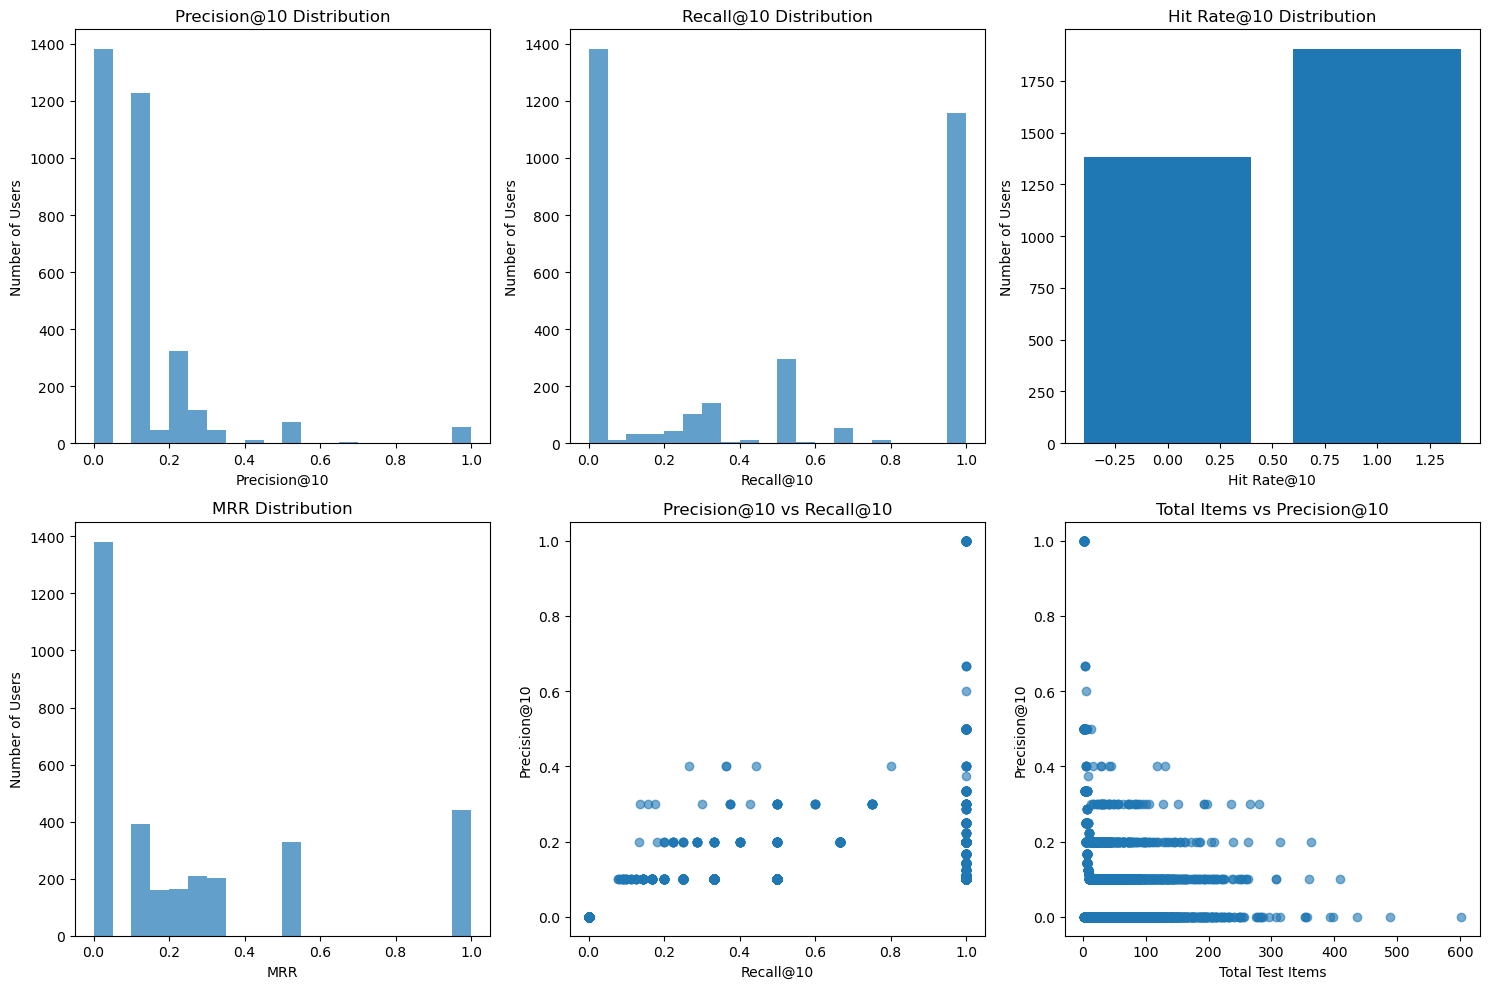


User case analysis completed! (k=10)
Analyzed 4 representative users out of 3286 total users


In [198]:
#User Case Analysis (k=10 version)
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def select_representative_users(all_scores, all_labels, all_users, user2idx, k=5):
    """
    Select representative users for case analysis
    """
    user_metrics = {}
    
    for u in np.unique(all_users):
        idx = (all_users == u)
        sc = all_scores[idx]
        lb = all_labels[idx]
        
        if len(sc) == 0:
            continue
            
        # Calculate metrics for this user (using k=10 for selection)
        order = np.argsort(-sc)
        topk = order[:10]  # Changed to k=10
        rels = lb[topk]
        total_rels = lb.sum()
        
        precision = rels.sum() / len(topk)
        recall = rels.sum() / total_rels if total_rels > 0 else 0.0
        hit_rate = 1.0 if rels.sum() > 0 else 0.0
        
        # Calculate MRR
        ranks = np.where(rels == 1)[0]
        mrr = 1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0
        
        user_metrics[u] = {
            'precision': precision,
            'recall': recall,
            'hit_rate': hit_rate,
            'mrr': mrr,
            'total_items': len(sc),
            'positive_items': total_rels
        }
    
    # Select users with different characteristics
    selected_users = []
    
    # 1. High performer (high precision and recall)
    high_performers = [(u, m) for u, m in user_metrics.items() 
                      if m['precision'] > 0.3 and m['recall'] > 0.5]
    if high_performers:
        selected_users.append(max(high_performers, key=lambda x: x[1]['precision'])[0])
    
    # 2. Low performer (low precision)
    low_performers = [(u, m) for u, m in user_metrics.items() 
                     if m['precision'] < 0.1 and m['total_items'] > 10]
    if low_performers:
        selected_users.append(min(low_performers, key=lambda x: x[1]['precision'])[0])
    
    # 3. Active user (many interactions)
    active_users = [(u, m) for u, m in user_metrics.items() 
                   if m['total_items'] > 50]
    if active_users:
        selected_users.append(max(active_users, key=lambda x: x[1]['total_items'])[0])
    
    # 4. Inactive user (few interactions)
    inactive_users = [(u, m) for u, m in user_metrics.items() 
                     if m['total_items'] < 20]
    if inactive_users:
        selected_users.append(min(inactive_users, key=lambda x: x[1]['total_items'])[0])
    
    # 5. Balanced user (medium performance)
    balanced_users = [(u, m) for u, m in user_metrics.items() 
                     if 0.1 <= m['precision'] <= 0.3 and 10 <= m['total_items'] <= 50]
    if balanced_users:
        selected_users.append(balanced_users[len(balanced_users)//2][0])
    
    # Ensure we have unique users and limit to k
    selected_users = list(set(selected_users))[:k]
    
    return selected_users, user_metrics

def analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=10):
    """
    Analyze individual user case (k=10)
    """
    # Find user's original ID
    user_id = None
    for orig_id, idx in user2idx.items():
        if idx == user_idx:
            user_id = orig_id
            break
    
    if user_id is None:
        print(f"User index {user_idx} not found in user2idx")
        return
    
    # Get user's data
    idx = (all_users == user_idx)
    sc = all_scores[idx]
    lb = all_labels[idx]
    
    if len(sc) == 0:
        print(f"No data found for user {user_id}")
        return
    
    # Get user's behavior from test data
    user_test_data = test_behaviour_sub[test_behaviour_sub['User_ID'] == user_id]
    
    print(f"\n{'='*60}")
    print(f"User Case Analysis: {user_id}")
    print(f"{'='*60}")
    
    # User statistics
    print(f"User Statistics:")
    print(f"- Total test items: {len(sc)}")
    print(f"- Positive items: {lb.sum()}")
    print(f"- Negative items: {len(sc) - lb.sum()}")
    print(f"- Positive ratio: {lb.sum()/len(sc):.3f}")
    
    # Calculate metrics (k=10)
    order = np.argsort(-sc)
    topk = order[:k]
    rels = lb[topk]
    total_rels = lb.sum()
    
    precision = rels.sum() / len(topk)
    recall = rels.sum() / total_rels if total_rels > 0 else 0.0
    hit_rate = 1.0 if rels.sum() > 0 else 0.0
    
    # Calculate MRR
    ranks = np.where(rels == 1)[0]
    mrr = 1.0 / (ranks[0] + 1) if ranks.size > 0 else 0.0
    
    # Calculate NDCG
    dcg = np.sum((2**rels - 1) / np.log2(np.arange(len(rels)) + 2))
    ideal = np.sort(lb)[::-1][:k]
    idcg = np.sum((2**ideal - 1) / np.log2(np.arange(len(ideal)) + 2))
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    print(f"\nTop-{k} Recommendation Performance:")
    print(f"- Precision@{k}: {precision:.4f}")
    print(f"- Recall@{k}: {recall:.4f}")
    print(f"- HitRate@{k}: {hit_rate:.4f}")
    print(f"- MRR: {mrr:.4f}")
    print(f"- NDCG@{k}: {ndcg:.4f}")
    
    # Show top recommendations
    print(f"\nTop-{k} Recommendations:")
    print(f"{'Rank':<6} {'Score':<8} {'Label':<6} {'News_ID':<15}")
    print("-" * 40)
    
    for i, rank in enumerate(topk):
        score = sc[rank]
        label = lb[rank]
        # Find news_id from news2idx
        news_id = None
        for orig_id, idx in news2idx.items():
            if idx == rank:
                news_id = orig_id
                break
        print(f"{i+1:<6} {score:<8.4f} {label:<6} {news_id:<15}")
    
    # User behavior analysis
    if not user_test_data.empty:
        print(f"\nUser Behavior Analysis:")
        history = user_test_data.iloc[0]['History'] if 'History' in user_test_data.columns else []
        if isinstance(history, str):
            history = history.split()
        print(f"- Historical clicks: {len(history)} items")
        print(f"- Test impressions: {len(sc)} items")
    
    # Performance summary
    print(f"\nPerformance Summary:")
    if precision > 0.3:
        print("- High precision: Model performs well for this user")
    elif precision > 0.1:
        print("- Medium precision: Model has moderate performance")
    else:
        print("- Low precision: Model struggles with this user")
    
    if hit_rate == 1.0:
        print("- High hit rate: At least one relevant item in top recommendations")
    else:
        print("- Low hit rate: No relevant items in top recommendations")
    
    if mrr > 0.5:
        print("- Good ranking: Relevant items appear early in recommendations")
    elif mrr > 0.2:
        print("- Moderate ranking: Relevant items appear in middle positions")
    else:
        print("- Poor ranking: Relevant items appear late in recommendations")

# Select representative users
representative_users = select_representative_users(all_scores, all_labels, all_users, user2idx)

print("Selected representative users:")
for i, user_idx in enumerate(representative_users[0]):
    print(f"{i+1}. User index: {user_idx}")

# Analyze each representative user (k=10)
for user_idx in representative_users[0]:
    analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=10)

# Overall user performance distribution (k=10)
print(f"\n{'='*60}")
print("Overall User Performance Distribution (k=10)")
print(f"{'='*60}")

user_metrics = representative_users[1]
if user_metrics:
    precisions = [m['precision'] for m in user_metrics.values()]
    recalls = [m['recall'] for m in user_metrics.values()]
    hit_rates = [m['hit_rate'] for m in user_metrics.values()]
    mrrs = [m['mrr'] for m in user_metrics.values()]
    
    print(f"Precision@10 distribution:")
    print(f"- Mean: {np.mean(precisions):.4f}")
    print(f"- Std: {np.std(precisions):.4f}")
    print(f"- Min: {np.min(precisions):.4f}")
    print(f"- Max: {np.max(precisions):.4f}")
    
    print(f"\nRecall@10 distribution:")
    print(f"- Mean: {np.mean(recalls):.4f}")
    print(f"- Std: {np.std(recalls):.4f}")
    print(f"- Min: {np.min(recalls):.4f}")
    print(f"- Max: {np.max(recalls):.4f}")
    
    print(f"\nHit Rate@10 distribution:")
    print(f"- Mean: {np.mean(hit_rates):.4f}")
    print(f"- Std: {np.std(hit_rates):.4f}")
    
    print(f"\nMRR distribution:")
    print(f"- Mean: {np.mean(mrrs):.4f}")
    print(f"- Std: {np.std(mrrs):.4f}")
    print(f"- Min: {np.min(mrrs):.4f}")
    print(f"- Max: {np.max(mrrs):.4f}")

# Visualization (k=10)
plt.figure(figsize=(15, 10))

# Precision distribution
plt.subplot(2, 3, 1)
plt.hist([m['precision'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Precision@10 Distribution')
plt.xlabel('Precision@10')
plt.ylabel('Number of Users')

# Recall distribution
plt.subplot(2, 3, 2)
plt.hist([m['recall'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Recall@10 Distribution')
plt.xlabel('Recall@10')
plt.ylabel('Number of Users')

# Hit Rate distribution
plt.subplot(2, 3, 3)
hit_rate_counts = Counter([m['hit_rate'] for m in user_metrics.values()])
plt.bar(hit_rate_counts.keys(), hit_rate_counts.values())
plt.title('Hit Rate@10 Distribution')
plt.xlabel('Hit Rate@10')
plt.ylabel('Number of Users')

# MRR distribution
plt.subplot(2, 3, 4)
plt.hist([m['mrr'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('MRR Distribution')
plt.xlabel('MRR')
plt.ylabel('Number of Users')

# Precision vs Recall scatter
plt.subplot(2, 3, 5)
precisions = [m['precision'] for m in user_metrics.values()]
recalls = [m['recall'] for m in user_metrics.values()]
plt.scatter(recalls, precisions, alpha=0.6)
plt.title('Precision@10 vs Recall@10')
plt.xlabel('Recall@10')
plt.ylabel('Precision@10')

# Total items vs Precision
plt.subplot(2, 3, 6)
total_items = [m['total_items'] for m in user_metrics.values()]
plt.scatter(total_items, precisions, alpha=0.6)
plt.title('Total Items vs Precision@10')
plt.xlabel('Total Test Items')
plt.ylabel('Precision@10')

plt.tight_layout()
plt.show()

print(f"\nUser case analysis completed! (k=10)")
print(f"Analyzed {len(representative_users[0])} representative users out of {len(user_metrics)} total users")

Selected representative users:
1. User index: 0
2. User index: 17
3. User index: 939
4. User index: 4180

User Case Analysis: U50864
User Statistics:
- Total test items: 28
- Positive items: 0
- Negative items: 28
- Positive ratio: 0.000

Top-20 Recommendation Performance:
- Precision@20: 0.0000
- Recall@20: 0.0000
- HitRate@20: 0.0000
- MRR: 0.0000
- NDCG@20: 0.0000

Top-20 Recommendations:
Rank   Score    Label  News_ID        
----------------------------------------
1      0.9225   0      N43620         
2      0.9001   0      N9680          
3      0.8191   0      N52386         
4      0.4922   0      N63175         
5      0.4817   0      N41387         
6      0.2462   0      N39758         
7      0.1741   0      N30389         
8      0.1628   0      N57356         
9      0.1514   0      N49265         
10     0.1334   0      N3395          
11     0.0583   0      N48239         
12     0.0581   0      N47705         
13     0.0358   0      N53526         
14     0.0236   0 

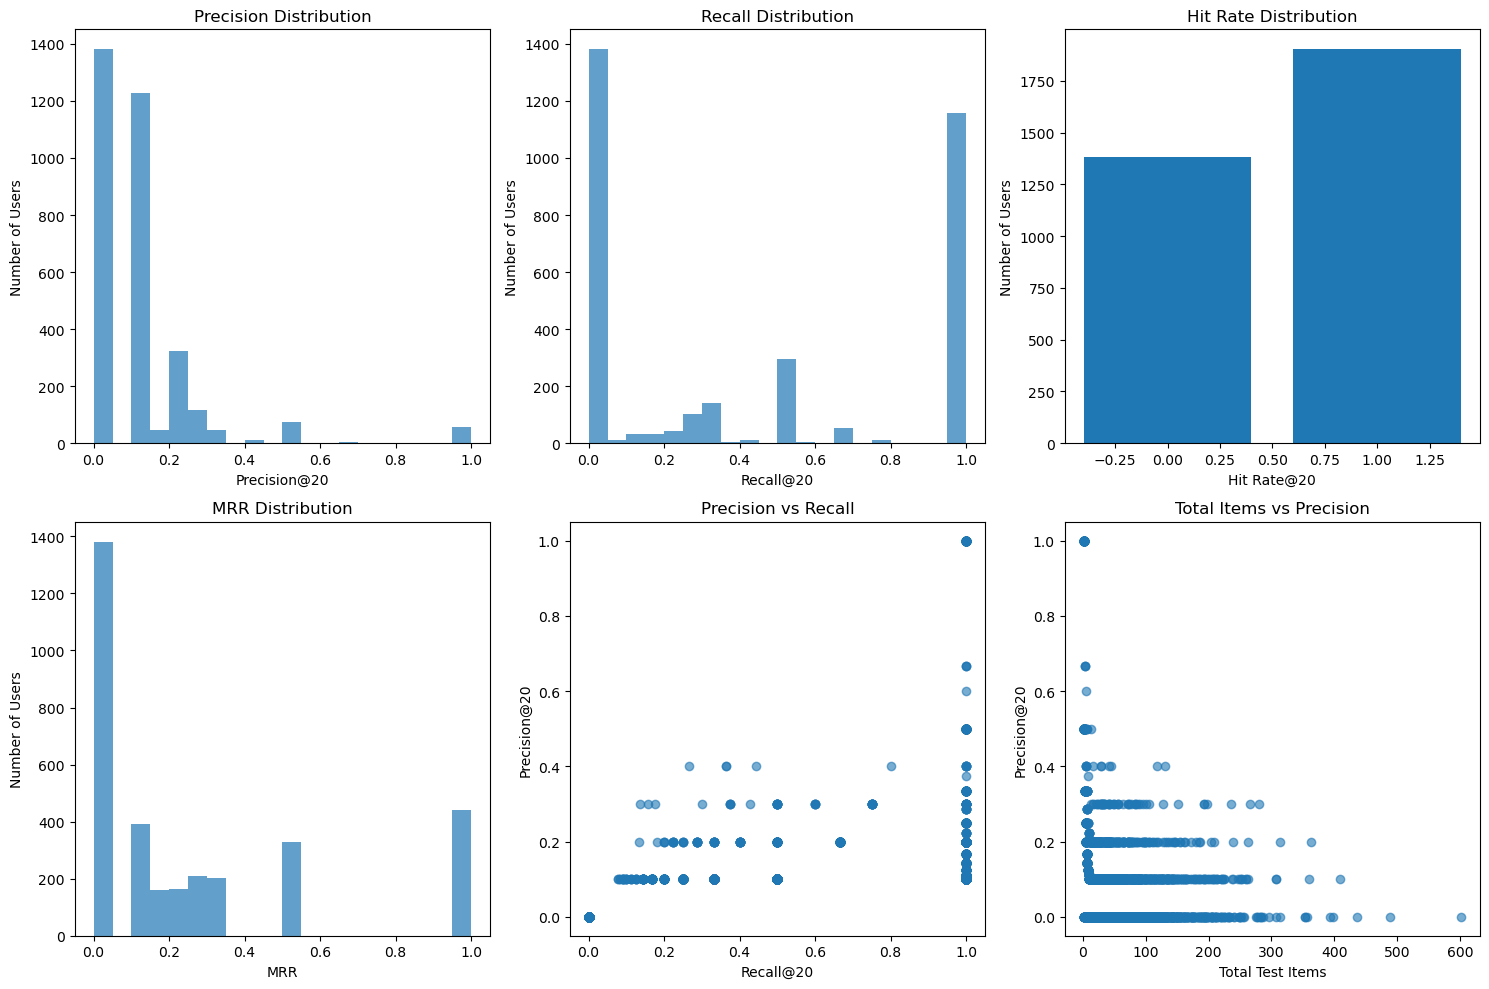


User case analysis completed!


In [199]:
# User Case Analysis(k=20 version)
# Select representative users
representative_users = select_representative_users(all_scores, all_labels, all_users, user2idx)

print("Selected representative users:")
for i, user_idx in enumerate(representative_users[0]):
    print(f"{i+1}. User index: {user_idx}")

# Analyze each representative user
for user_idx in representative_users[0]:
    analyze_user_case(user_idx, all_scores, all_labels, all_users, user2idx, news2idx, test_behaviour_sub, k=20)

# Overall user performance distribution
print(f"\n{'='*60}")
print("Overall User Performance Distribution")
print(f"{'='*60}")

user_metrics = representative_users[1]
if user_metrics:
    precisions = [m['precision'] for m in user_metrics.values()]
    recalls = [m['recall'] for m in user_metrics.values()]
    hit_rates = [m['hit_rate'] for m in user_metrics.values()]
    mrrs = [m['mrr'] for m in user_metrics.values()]
    
    print(f"Precision distribution:")
    print(f"- Mean: {np.mean(precisions):.4f}")
    print(f"- Std: {np.std(precisions):.4f}")
    print(f"- Min: {np.min(precisions):.4f}")
    print(f"- Max: {np.max(precisions):.4f}")
    
    print(f"\nRecall distribution:")
    print(f"- Mean: {np.mean(recalls):.4f}")
    print(f"- Std: {np.std(recalls):.4f}")
    print(f"- Min: {np.min(recalls):.4f}")
    print(f"- Max: {np.max(recalls):.4f}")
    
    print(f"\nHit Rate distribution:")
    print(f"- Mean: {np.mean(hit_rates):.4f}")
    print(f"- Std: {np.std(hit_rates):.4f}")
    
    print(f"\nMRR distribution:")
    print(f"- Mean: {np.mean(mrrs):.4f}")
    print(f"- Std: {np.std(mrrs):.4f}")
    print(f"- Min: {np.min(mrrs):.4f}")
    print(f"- Max: {np.max(mrrs):.4f}")

# Visualization
plt.figure(figsize=(15, 10))

# Precision distribution
plt.subplot(2, 3, 1)
plt.hist([m['precision'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Precision Distribution')
plt.xlabel('Precision@20')
plt.ylabel('Number of Users')

# Recall distribution
plt.subplot(2, 3, 2)
plt.hist([m['recall'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('Recall Distribution')
plt.xlabel('Recall@20')
plt.ylabel('Number of Users')

# Hit Rate distribution
plt.subplot(2, 3, 3)
hit_rate_counts = Counter([m['hit_rate'] for m in user_metrics.values()])
plt.bar(hit_rate_counts.keys(), hit_rate_counts.values())
plt.title('Hit Rate Distribution')
plt.xlabel('Hit Rate@20')
plt.ylabel('Number of Users')

# MRR distribution
plt.subplot(2, 3, 4)
plt.hist([m['mrr'] for m in user_metrics.values()], bins=20, alpha=0.7)
plt.title('MRR Distribution')
plt.xlabel('MRR')
plt.ylabel('Number of Users')

# Precision vs Recall scatter
plt.subplot(2, 3, 5)
precisions = [m['precision'] for m in user_metrics.values()]
recalls = [m['recall'] for m in user_metrics.values()]
plt.scatter(recalls, precisions, alpha=0.6)
plt.title('Precision vs Recall')
plt.xlabel('Recall@20')
plt.ylabel('Precision@20')

# Total items vs Precision
plt.subplot(2, 3, 6)
total_items = [m['total_items'] for m in user_metrics.values()]
plt.scatter(total_items, precisions, alpha=0.6)
plt.title('Total Items vs Precision')
plt.xlabel('Total Test Items')
plt.ylabel('Precision@20')

plt.tight_layout()
plt.show()

print(f"\nUser case analysis completed!")
